In [4]:
import ast
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from datasets import load_dataset

dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x)else x)

In [8]:
import seaborn as sns

In [2]:
df_DA_ch= df[(df['job_title_short']== 'Data Analyst') & (df['job_country'] == 'Chile')].copy()

df_DA_ch = df_DA_ch.dropna(subset=['salary_year_avg'])

In [5]:
df_DA_ch = df_DA_ch.explode('job_skills')

In [9]:
df_DA_ch_group = df_DA_ch.groupby('job_skills')['salary_year_avg'].agg(['count', 'median'])

df_DA_ch_top_pay = df_DA_ch_group.sort_values(by='median', ascending=False).head(10)

df_DA_skills = df_DA_ch_group.sort_values(by='count', ascending=False).head(10).sort_values(by='median', ascending=False)

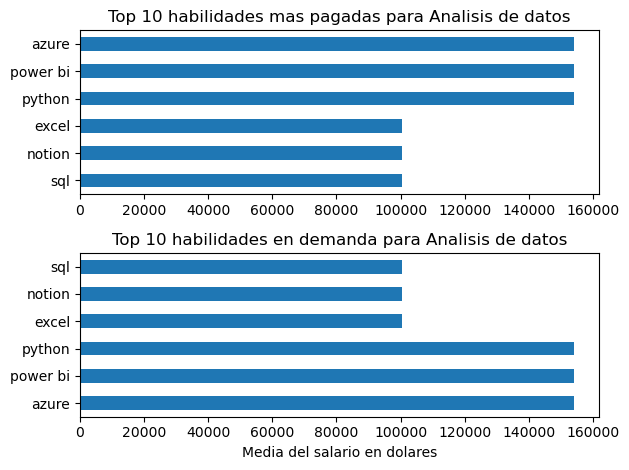

In [10]:
fig, ax = plt.subplots(2, 1)


df_DA_ch_top_pay.plot(kind='barh', y='median', ax=ax[0], legend=False)
ax[0].invert_yaxis()
ax[0].set_title('Top 10 habilidades mas pagadas para Analisis de datos')
ax[0].set_ylabel('')
ax[0].set_xlabel('')
df_DA_skills.plot(kind='barh', y='median', ax=ax[1], legend=False)
ax[1].set_xlim((ax[0]).get_xlim())
ax[1].set_title('Top 10 habilidades en demanda para Analisis de datos')
ax[1].set_ylabel('')
ax[1].set_xlabel('Media del salario en dolares')


fig.tight_layout()
plt.show()

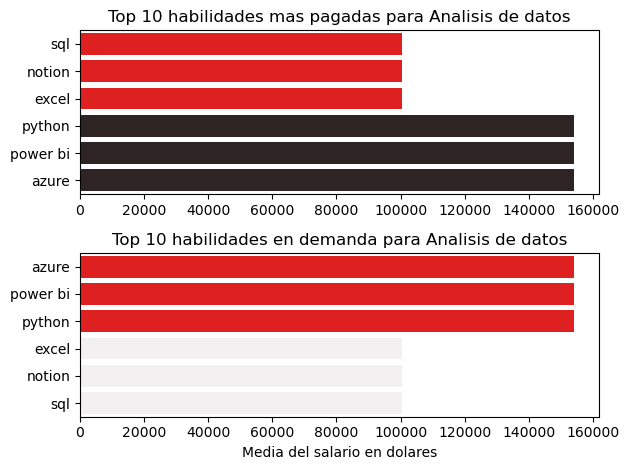

In [16]:
fig, ax = plt.subplots(2, 1)

sns.barplot(data=df_DA_ch_top_pay, x='median', y=df_DA_ch_top_pay.index, ax=ax[0], hue='median', palette='dark:r_r')
ax[0].legend().remove()
#df_DA_ch_top_pay.plot(kind='barh', y='median', ax=ax[0], legend=False)
ax[0].invert_yaxis()
ax[0].set_title('Top 10 habilidades mas pagadas para Analisis de datos')
ax[0].set_ylabel('')
ax[0].set_xlabel('')

sns.barplot(data=df_DA_skills, x='median', y=df_DA_skills.index, ax=ax[1], hue='median', palette='light:r')
ax[1].legend().remove()
#df_DA_skills.plot(kind='barh', y='median', ax=ax[1], legend=False)
ax[1].set_xlim((ax[0]).get_xlim())
ax[1].set_title('Top 10 habilidades en demanda para Analisis de datos')
ax[1].set_ylabel('')
ax[1].set_xlabel('Media del salario en dolares')


fig.tight_layout()
plt.show()